In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Load Data

In [2]:
df=pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

In [3]:
df.head()
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None


# Data Cleaning 

In [4]:
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [5]:
df.drop_duplicates(inplace=True)

# EDA

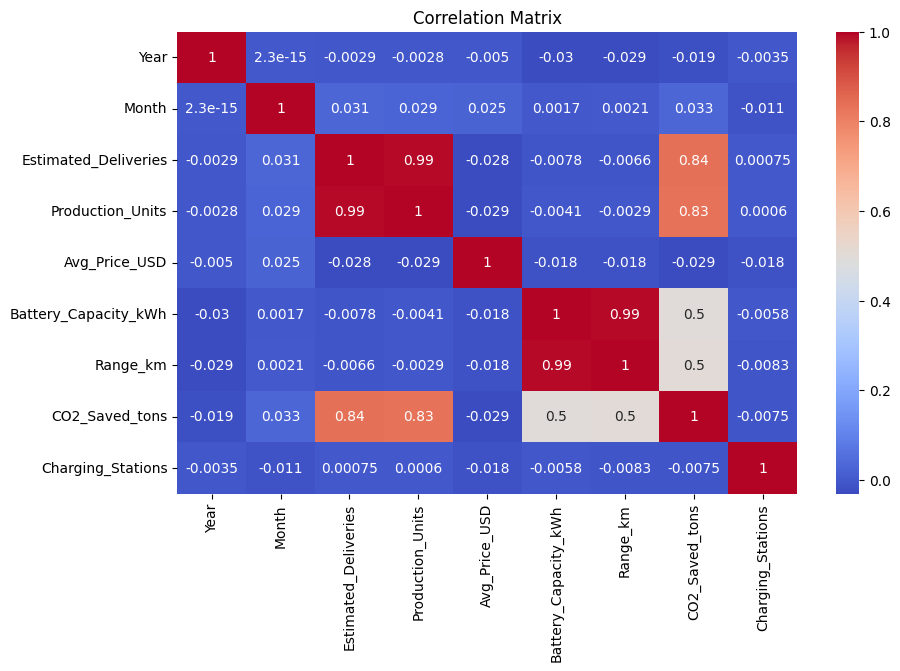

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


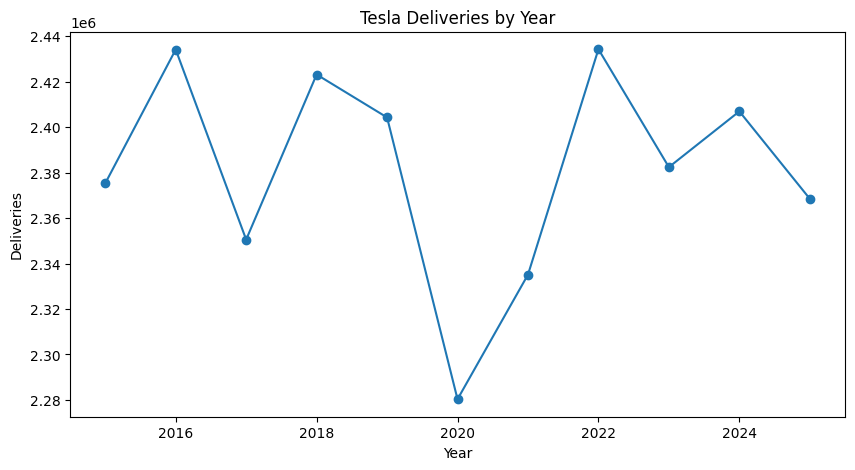

In [7]:
yearly_deliveries = df.groupby("Year")["Estimated_Deliveries"].sum()

plt.figure(figsize=(10,5))
yearly_deliveries.plot(kind="line", marker="o")
plt.title("Tesla Deliveries by Year")
plt.ylabel("Deliveries")
plt.show()

# Feature Encoding

In [8]:
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df["Region"] = le_region.fit_transform(df["Region"])
df["Model"] = le_model.fit_transform(df["Model"])
df["Source_Type"] = le_source.fit_transform(df["Source_Type"])

# Feature Selection


In [9]:
X = df.drop("Estimated_Deliveries", axis=1)
y = df["Estimated_Deliveries"]

# Train Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Random Forest Model

In [11]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

predictions = rf.predict(X_test)

# Evaluation

In [12]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 323.46011363636364
RMSE: 409.4960252956731
R2 Score: 0.9887505867840798


# Hyperparameter Tuning


In [13]:
params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

best_model = grid.best_estimator_


Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.9881702545469474


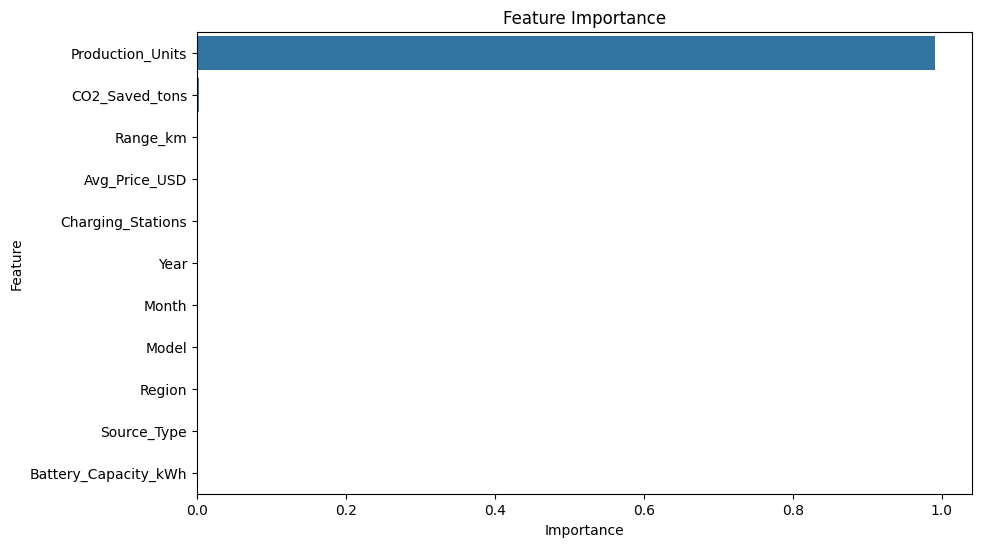

In [14]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance")
plt.show()


# Time Series Forecasting

In [18]:
from sklearn.linear_model import LinearRegression
import numpy as np

yearly = df.groupby("Year")["Estimated_Deliveries"].sum()

X = yearly.index.values.reshape(-1,1)
y = yearly.values

model = LinearRegression()
model.fit(X,y)

future_years = np.array([2026,2027,2028]).reshape(-1,1)

pred = model.predict(future_years)

for year,val in zip(future_years.flatten(), pred):
    print(f"{year}: {val:.0f}")

2026: 2376197
2027: 2375342
2028: 2374487


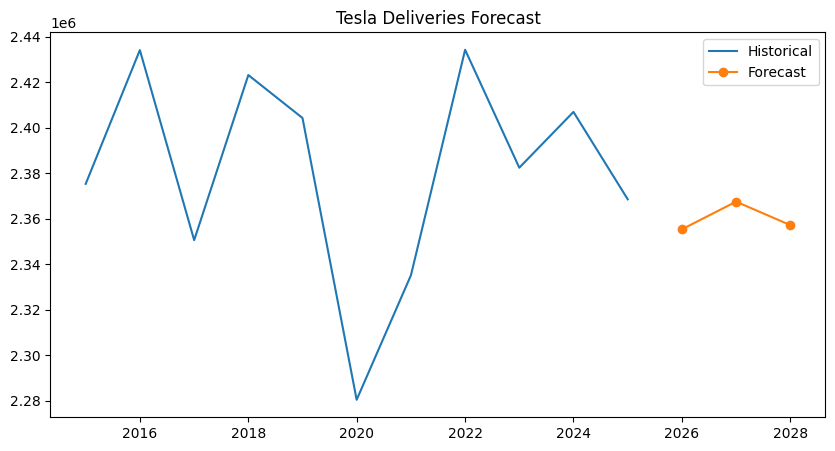

In [20]:
future_dates = pd.date_range(
    start=ts.index.max() + pd.DateOffset(years=1),
    periods=3,
    freq='YS'
)

plt.figure(figsize=(10,5))

plt.plot(ts.index, ts.values, label="Historical")
plt.plot(
    future_dates,
    forecast,
    marker='o',
    label='Forecast'
)

plt.legend()
plt.title("Tesla Deliveries Forecast")
plt.show()